# Convolutional Neural Network For Handwritten Digit Recognition Using PyTorch

## Importing All Essential Packages

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder

from PIL import Image


## Inspecting Dataset

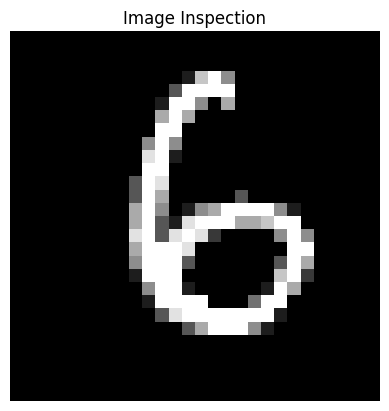

In [2]:
inspect_img = Image.open("../data/mnistmini/training/6/7220.png")

plt.title("Image Inspection")
plt.imshow(inspect_img, cmap = "gray")
plt.axis("off")
plt.show()

## Loading Dataset

In [19]:
seed = 67

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [20]:
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees = 0, translate = (0.1, 0.1)),

    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

In [21]:
full_training_dataset = ImageFolder("../data/mnistmini/training")

indices = list(range(len(full_training_dataset)))
targets = full_training_dataset.targets

train_idx, val_idx = train_test_split(
    indices,
    test_size = 0.2,
    stratify = targets,
    random_state = seed
)

train_data = Subset(full_training_dataset, train_idx)
val_data = Subset(full_training_dataset, val_idx)

train_data.dataset.transform = train_transform
val_data.dataset.transfrom = val_transform

In [22]:
train_loader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    val_data,
    batch_size = 32,
    shuffle = False
)

## Model Architecture and Creation